# 05 - COVID-19 Temporal Analysis

This notebook analyzes how did **cases and deaths evolve over time** and which **events changed its behavior (lockdown, restrictions, vaccinations)**.

Includes:
* Cases and deaths (per capita)
* Moving averages
* Key dates:
    - First global lockdown
    - Initial restrictions
    - Initial vaccination 

Objective:
> Detect structural changes

## Import Libraries

In [2]:
import os
from pathlib import Path

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
os.chdir(project_root)

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the data loader module
from src.data_loader import change_dtypes
from src.visualization import set_style

# Set visualization style
set_style(palette="Blues_d")

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Data

In [4]:
countries = pd.read_csv("data/processed/countries.csv", parse_dates=["date"])
countries.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39


## Global Evolution of Cases

Here we are going to see how cases evolved.

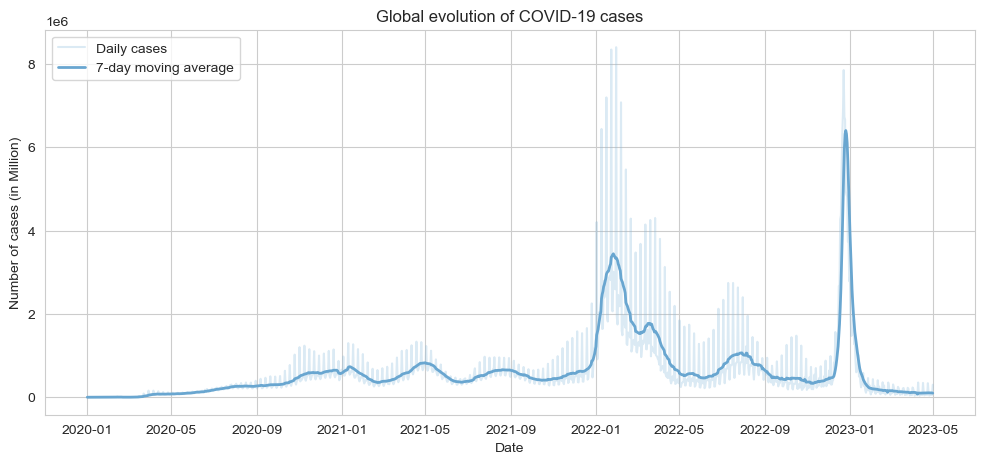

In [5]:
global_cases = (
    countries
    .groupby("date", as_index=False)["new_cases"]
    .sum()
)

global_cases["cases_ma7"] = global_cases["new_cases"].rolling(7).mean().fillna(0)

# Graph
plt.figure(figsize=(12, 5))
plt.plot(global_cases["date"], global_cases["new_cases"], alpha=0.3, label="Daily cases")
plt.plot(global_cases["date"], global_cases["cases_ma7"], linewidth=2, label="7-day moving average")

plt.title("Global evolution of COVID-19 cases")
plt.xlabel("Date")
plt.ylabel("Number of cases (in Million)")
plt.legend()
plt.show()

> Observation: as we can see in the daily cases lines and in our data, new cases are very volatile as sometimes there are no report cases at all (weekends) or some days there are a lot of them. That is why we choose to use the moving average as the line of tendency, because we can see more clearely the cases over time.

Also, we can see that there were big case waves on early 2022 and 2023.

But... what happened in the early stages of the virus? We are going to see what happened on the first year 2020 and important dates.

### 2020 - The Beginning of the COVID

This is one of the news reporting that the first COVID-19 case was detected on 17 November 2019, according to the China government.

<img src="../img/first_covid_case.png" width="600">

After this first case was reported, the cases started to grow, and since **11 March 2020** COVID-19 has been a pandemic.

The COVID started to be very contagious and by middle of March 2020, the first lockdowns started to take place. 

> **By April 2020**, most of the world was locked down in their houses.

*This is a visualization of the early stage of the pandemic in relation to daily cases, until June 2020.*

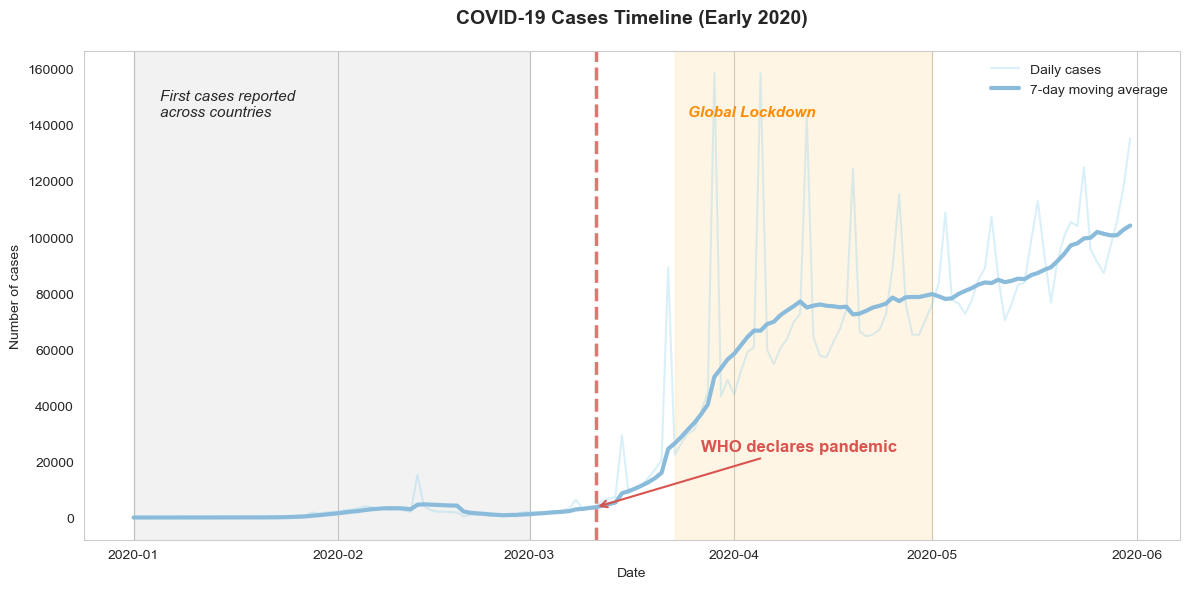

In [6]:
global_cases_2020 = global_cases.query("date < '2020/06'")

set_style(palette="Blues_d")

# Graph
plt.figure(figsize=(12, 6))

# Daily cases
sns.lineplot(data=global_cases_2020, x="date", y="new_cases", 
             alpha=0.3, label="Daily cases", color="skyblue")

# moving average
sns.lineplot(data=global_cases_2020, x="date", y="cases_ma7", 
             linewidth=3, label="7-day moving average")

# --- ANNOTATIONS ---

# A. Period: First cases reported (Jan to March)
plt.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-03-01"), 
            color='gray', alpha=0.1)
plt.text(pd.Timestamp("2020-01-05"), plt.ylim()[1]*0.86, 
         "First cases reported\nacross countries", 
         fontsize=11, fontstyle='italic')

# B. WHO Pandemic Declaration (March 11)
pandemic_date = pd.Timestamp("2020-03-11")
plt.axvline(x=pandemic_date, color='#d9534f', linestyle='--', alpha=0.8, lw=2.5) # Rojo suave

y_value = global_cases_2020.loc[global_cases_2020["date"] == pandemic_date, "cases_ma7"].values[0]

plt.annotate('WHO declares pandemic', 
             xy=(pandemic_date, y_value),
             xytext=(pd.Timestamp("2020-03-27"), y_value + (plt.ylim()[1]*0.12)),
             arrowprops=dict(arrowstyle='->', color='#d9534f', lw=1.5),
             color='#d9534f',
             fontsize=12, fontweight='bold')

# C. First global lockdowns
plt.axvspan(pd.Timestamp("2020-03-23"), pd.Timestamp("2020-05-01"), 
            color='orange', alpha=0.10)
plt.text(pd.Timestamp("2020-03-25"), plt.ylim()[1]*0.86, 
         "Global Lockdown", 
         fontsize=11, color='darkorange', fontweight='bold', fontstyle="italic")

plt.title("COVID-19 Cases Timeline (Early 2020)", fontsize=14, pad=20, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Number of cases")
plt.legend(frameon=False)

plt.gca().yaxis.grid(False)
plt.tight_layout()
plt.show()

### The evolution of COVID-19

But this is not all... we have to analyze 2 other **phenomena** that were key in the development of COVID-19 pandemic.

* **Seasonality**: if we see the cases until 2023, we can see that cases raised considerably in January 2022 and December 2023. This was mainly because of Christmas Holidays. People started to meet and cases started to raise. 
> Also, we have to take into account that the virus survived better in cold and dry environments, and the north hemisphere had those conditions at that time.

* **COVID-19 Variants**: we also have to analyze the effects of variants of the virus, as some variants were reported to be extremely dangerous.

    These were the most dangerous variants:

    * **Alfa (The First Global Concern)**: it was a lot more contagious than the Original COVID-19 but it was pretty lethal due to the lack of vaccination in final of 2020.

    * **Delta (Most Lethal)**: in relative terms, it caused the most number of hospitalizations and deaths in people not vaccinated. It appeared in final 2020, but went global on 2021.

    * **Ómicron (Most Contagious)**: it was the variant with most mutations. This allowed it "evade" part of the vaccines immunity and spread at a tremendous speed. However, due to the vaccination, Omicron was not as lethal as Delta. It appeared in november 2021.

    > Now, we are going to visualize cases, but later we will use deaths and these variants will be important.

<br>

***And what about the peak in 2023?***

***If we look at China, during almost 3 years, they kept extreme restrictions. But in december 2022, the government removed these restrictions. This provoked a lot of new cases registered massively. This situation was also mixed up with the BF.7 Variant, an evolution of the Omicron one extremely contagious.***

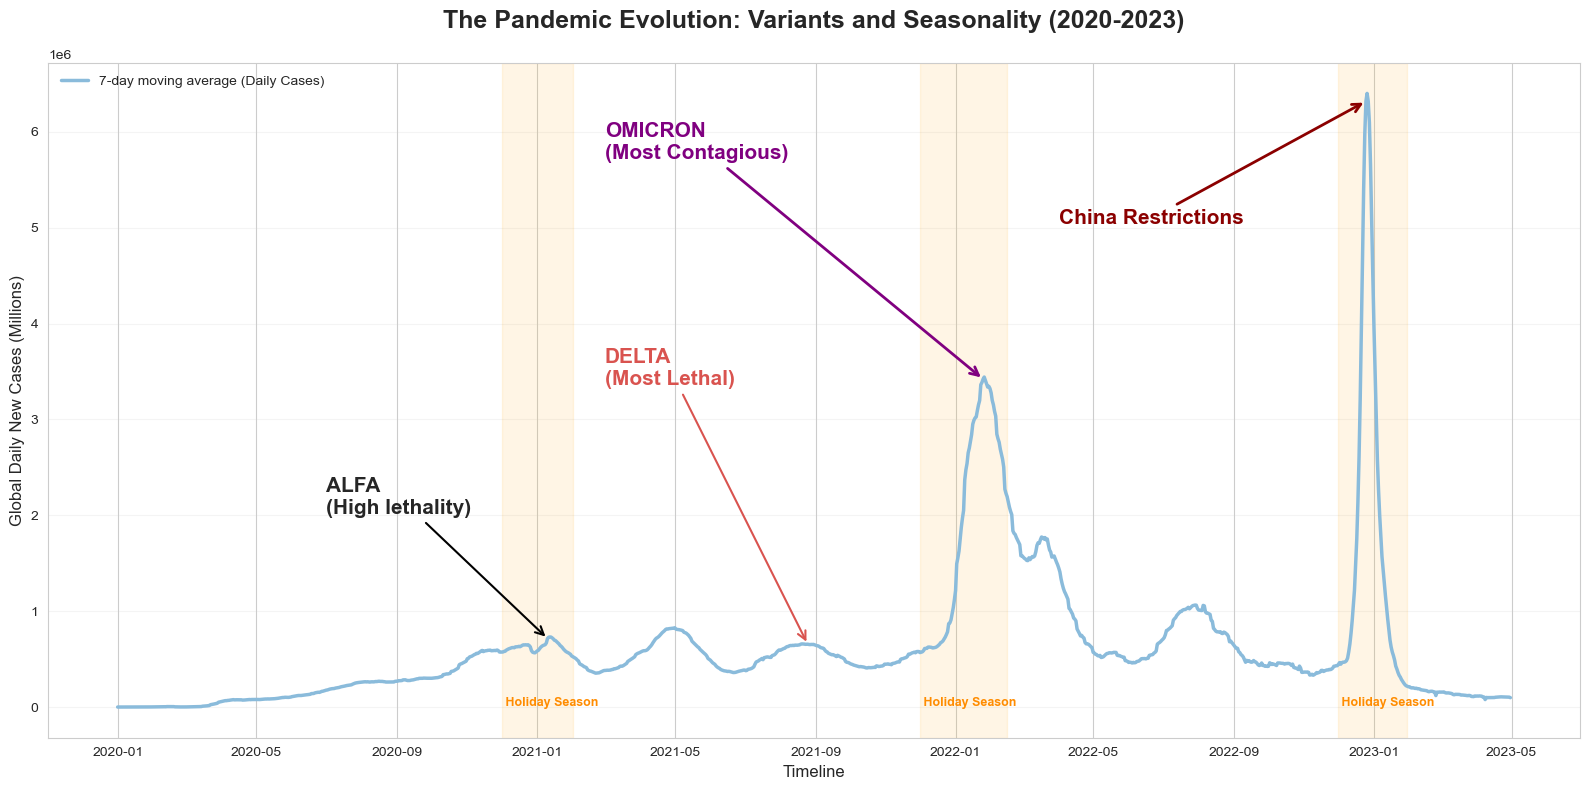

In [7]:
global_cases_full = global_cases.query("date < '2023-06-01'")
set_style(palette="Blues_d")

plt.figure(figsize=(16, 8))

# Moving average of cases
sns.lineplot(data=global_cases_full, x="date", y="cases_ma7", 
             linewidth=2.5, label="7-day moving average (Daily Cases)")

# --- PHENOMENON 1: SEASONALITY (Winter / Holidays) ---
winter_periods = [
    ("2020-12-01", "2021-02-01", "Winter Surge 2020 (Alpha)"),
    ("2021-12-01", "2022-02-15", "Winter Surge 2021 (Omicron)"),
    ("2022-12-01", "2023-01-30", "Winter Surge 2022")
]

for start, end, label in winter_periods:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='orange', alpha=0.1)
    
    plt.text(pd.Timestamp(start), plt.ylim()[1]*0.001, " Holiday Season", 
             color='darkorange', fontsize=9, fontweight='bold')

# --- PHENOMENON 2: COVID-19 VARIANTS ---

# A. ALPHA (End 2020)
alpha_date = pd.Timestamp("2021-01-10")
plt.annotate('ALFA\n(High lethality)', 
             xy=(alpha_date, global_cases_full.loc[global_cases_full["date"] == alpha_date, "cases_ma7"].values[0]),
             xytext=(pd.Timestamp("2020-07-01"), plt.ylim()[1]*0.3),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=15, fontweight="bold")

# B. DELTA (Summer/Autumn 2021)
delta_date = pd.Timestamp("2021-08-25")
plt.annotate('DELTA\n(Most Lethal)', 
             xy=(delta_date, global_cases_full.loc[global_cases_full["date"] == delta_date, "cases_ma7"].values[0]),
             xytext=(pd.Timestamp("2021-03-01"), plt.ylim()[1]*0.5),
             arrowprops=dict(arrowstyle='->', color='#d9534f', lw=1.5),
             color='#d9534f', fontsize=15, fontweight='bold')

# C. OMICRON (Massive peak 2022)
omicron_date = pd.Timestamp("2022-01-25")
plt.annotate('OMICRON\n(Most Contagious)', 
             xy=(omicron_date, global_cases_full.loc[global_cases_full["date"] == omicron_date, "cases_ma7"].values[0]),
             xytext=(pd.Timestamp("2021-03-01"), plt.ylim()[1]*0.85),
             arrowprops=dict(arrowstyle='->', color='purple', lw=2),
             color='purple', fontsize=15, fontweight='bold')

# D. CHINA EXIT (January 2023)
china_surge_date = pd.Timestamp("2022-12-25")
plt.annotate('China Restrictions', 
             xy=(china_surge_date, global_cases_full.loc[global_cases_full["date"] == china_surge_date, "cases_ma7"].values[0]),
             xytext=(pd.Timestamp("2022-04-01"), plt.ylim()[1]*0.75), # Texto bien arriba
             arrowprops=dict(arrowstyle='->', color='darkred', lw=2),
             color='darkred', fontsize=15, fontweight='bold')

plt.title("The Pandemic Evolution: Variants and Seasonality (2020-2023)", fontsize=18, pad=25, fontweight="bold")
plt.ylabel("Global Daily New Cases (Millions)", fontsize=12)
plt.xlabel("Timeline", fontsize=12)
plt.yscale('linear')
plt.grid(axis='y', alpha=0.2)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

## Global Evolution of Deaths

After analyzing all of this, we have to see the behavior of the virus in relation to deaths.

Here, we are going to analyze how variants, vaccinations and restrictions affected deaths.

In [ ]:
# 1.Group deaths by date and cases
global_cases = (
    countries
    .groupby("date", as_index=False)[["new_cases", "new_deaths", "new_cases_per_million", "new_deaths_per_million"]]
    .sum()
)

# 2. Moving Average
# Cases
global_cases["cases_ma7"] = global_cases["new_cases"].rolling(7).mean().fillna(0)
global_cases["cases_per_million_ma7"] = global_cases["new_cases_per_million"].rolling(7).mean().fillna(0)

# Deaths
global_cases["deaths_ma7"] = global_cases["new_deaths"].rolling(7).mean().fillna(0)
global_cases["deaths_per_million_ma7"] = global_cases["new_deaths_per_million"].rolling(7).mean().fillna(0)

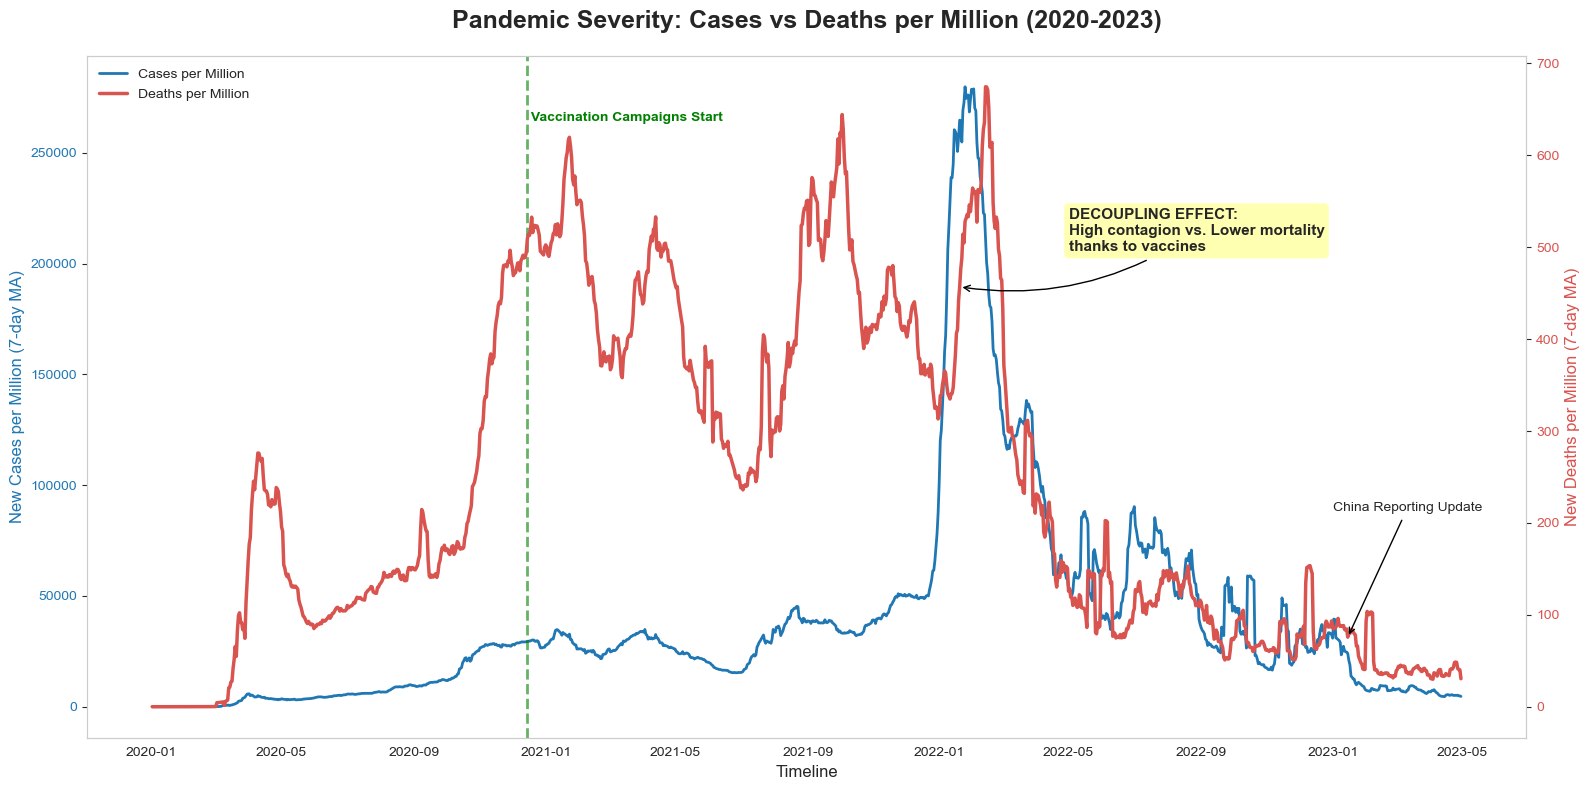

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filter dates
global_data = global_cases.query("date > '2020-01-01' and date < '2023-06-01'")

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- CASES PER MILLION (BLUE) ---
color_cases = '#1f77b4'
ax1.set_xlabel('Timeline', fontsize=12)
ax1.set_ylabel('New Cases per Million (7-day MA)', color=color_cases, fontsize=12)
sns.lineplot(data=global_data, x='date', y='cases_per_million_ma7', 
             color=color_cases, ax=ax1, linewidth=2, label="Cases per Million")
ax1.tick_params(axis='y', labelcolor=color_cases)
ax1.grid(False) 

# --- DEATHS PER MILLION (RED) ---
ax2 = ax1.twinx() 
color_deaths = '#d9534f'
ax2.set_ylabel('New Deaths per Million (7-day MA)', color=color_deaths, fontsize=12)
sns.lineplot(data=global_data, x='date', y='deaths_per_million_ma7', 
             color=color_deaths, ax=ax2, linewidth=2.5, label="Deaths per Million")
ax2.tick_params(axis='y', labelcolor=color_deaths)
ax2.grid(False)

# --- KEY DATES ---

# A. Initial Vaccination (December 2020)
vax_start = pd.Timestamp("2020-12-15")
ax1.axvline(vax_start, color='green', linestyle='--', alpha=0.6, lw=2)
ax1.text(vax_start, ax1.get_ylim()[1]*0.9, " Vaccination Campaigns Start", color='green', fontweight='bold')

# B. "Decoupling Effect" (Ómicron 2022)
target_date = pd.Timestamp("2022-01-20")
y_death_val = global_data.loc[global_data['date'] == target_date, 'deaths_per_million_ma7'].values[0]

ax2.annotate('DECOUPLING EFFECT:\nHigh contagion vs. Lower mortality\nthanks to vaccines', 
             xy=(target_date, y_death_val),
             xytext=(pd.Timestamp("2022-05-01"), ax2.get_ylim()[1]*0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=-0.2", color='black'),
             fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

# C. China Update
china_date = pd.Timestamp("2023-01-15")
y_china_val = global_data.loc[global_data['date'] == china_date, 'deaths_per_million_ma7'].values[0]
ax2.annotate('China Reporting Update', 
             xy=(china_date, y_china_val),
             xytext=(pd.Timestamp("2023-01-01"), ax2.get_ylim()[1]*0.3),
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title("Pandemic Severity: Cases vs Deaths per Million (2020-2023)", fontsize=18, pad=20, fontweight="bold")

# Same legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=False)
ax2.get_legend().remove() 

fig.tight_layout()
plt.show()

As we can see, as vaccination campaigns started, the population started to be stronger against the virus, and in the most contagious variant (Omicron), the global population had obviously an increase in deaths, but not as much as it would have been without vaccination. This is what we call **Decoupling Effect**.

There is another pattern we can observe in this graph. The lines are obviously correlated, but they have a little temporal "lag". This is due to the fact that the **deaths do not occur the same day as the contagion**, they have a delay of 14 to 21 days.

Also, we can see that after Omicron variant, the global cases per million went down drastically, and the virus seemed to be more or less under control globally. But we have to interpret this carefully, as countries started to stop testing massively and people could perform a COVID-19 test by themselves in their houses.

## Vaccination

We are going to analyze if the vaccination was true and if it had an effect in the Decoupling Effect.

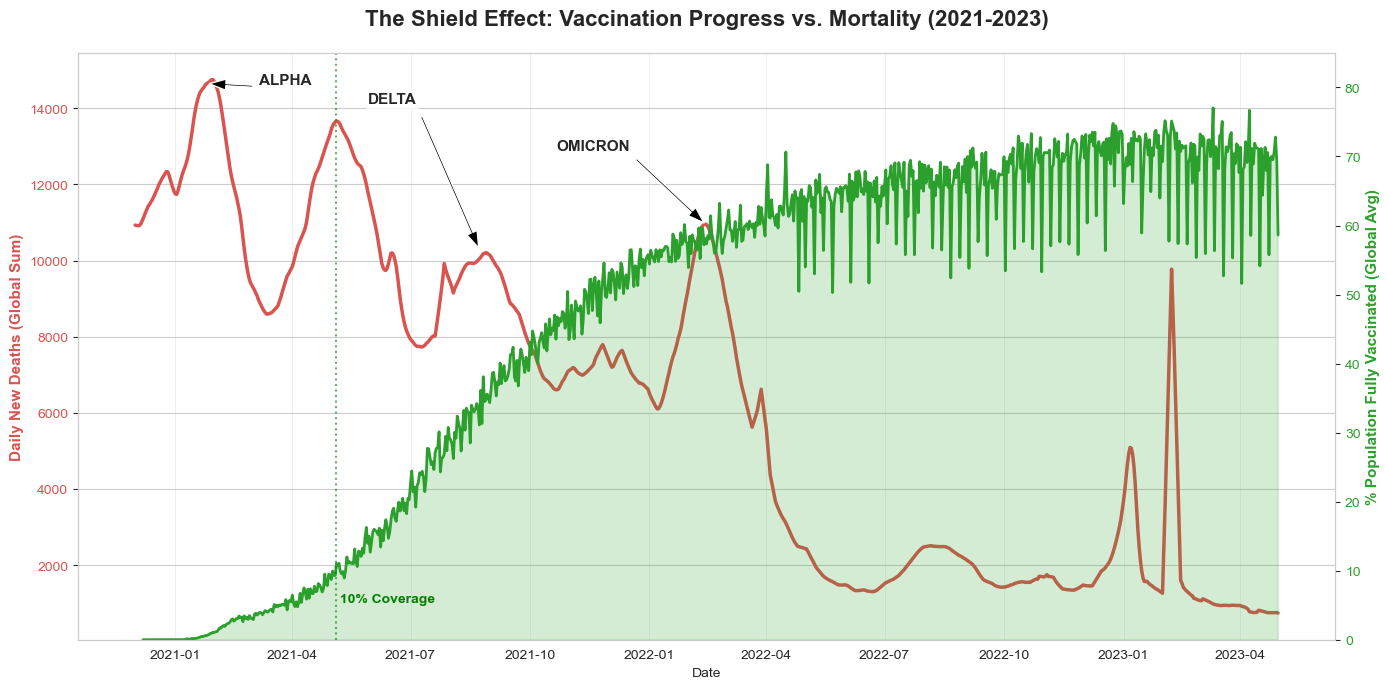

In [68]:
# 1. PREPARE DATA
vax_evolution = (
    countries
    .groupby("date")
    .agg({
        'people_fully_vaccinated_per_hundred': 'mean',
        'new_deaths_smoothed': 'sum'
    })
    .reset_index()
)

vax_evolution['deaths_ma7'] = vax_evolution['new_deaths_smoothed'].rolling(7).mean()
vax_data = vax_evolution.query("date >= '2020-12-01' and date < '2023-06-01'")

# 2. VISUALIZATION
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- AXIS 1 (RIGHT): VACCINATION ---
color_vax = 'tab:green'
ax2 = ax1.twinx()
ax2.set_ylabel('% Population Fully Vaccinated (Global Avg)', color=color_vax, fontweight='bold', fontsize=11)
ax2.fill_between(vax_data['date'], vax_data['people_fully_vaccinated_per_hundred'], 
                 color=color_vax, alpha=0.2, label='Vaccination Coverage')
ax2.plot(vax_data['date'], vax_data['people_fully_vaccinated_per_hundred'], 
         color=color_vax, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_vax)
ax2.set_ylim(0, 85)
ax2.grid(False)

# --- AXIS 2 (LEFT): DEATHS ---
color_death = '#d9534f'
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily New Deaths (Global Sum)', color=color_death, fontweight='bold', fontsize=11)
ax1.plot(vax_data['date'], vax_data['deaths_ma7'], 
         color=color_death, linewidth=2.5, linestyle='-', label='Daily Deaths (7-day MA)')
ax1.tick_params(axis='y', labelcolor=color_death)
ax1.grid(axis='x', alpha=0.3)

# --- ANNOTATIONS (VARIANTS) ---

variants_config = {
    'ALPHA': {
        'date': '2021-01-25',
        'days_shift': 40,     
        'y_shift': 0,
        'align': 'left'
    },
    'DELTA': {
        'date': '2021-08-25',
        'days_shift': -50,    
        'y_shift': 4000,      
        'align': 'right'      
    },
    'OMICRON': {
        'date': '2022-02-15',
        'days_shift': -60,    
        'y_shift': 2000,     
        'align': 'right'
    }
}

for name, config in variants_config.items():
    target_date = pd.to_datetime(config['date'])
    
    # Find Y value
    try:
        closest_idx = (vax_data['date'] - target_date).abs().idxmin()
        row = vax_data.loc[closest_idx]
        actual_date = row['date']
        y_val = row['deaths_ma7']
        
        # Calculate text position
        text_date = actual_date + pd.Timedelta(days=config['days_shift'])
        text_y = y_val + config['y_shift']
        
        ax1.annotate(name, 
                     xy=(actual_date, y_val),             # Punta de la flecha
                     xytext=(text_date, text_y),          # Texto
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     fontsize=11, fontweight='bold', ha=config['align'],
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, edgecolor='none'))
    except:
        pass

# --- 10% VACCINATION LINE ---
try:
    date_10pct = vax_data[vax_data['people_fully_vaccinated_per_hundred'] >= 10].iloc[0]['date']
    ax2.axvline(date_10pct, color='green', linestyle=':', alpha=0.6)
    ax2.text(date_10pct, 5, " 10% Coverage", color='green', fontweight='bold', rotation=0, va='bottom')
except:
    pass

# Titles & Layout
plt.title("The Shield Effect: Vaccination Progress vs. Mortality (2021-2023)", fontsize=16, pad=20, fontweight="bold")
fig.tight_layout()

plt.show()

The visual evidence is strong. The graph demonstrates an inverse relationship between new deaths and people fully vaccinated, even in the Omicron variant, reporting less cases than in previous waves.

* **2021 (The Race):** As the green area (vaccination coverage) grows slowly, we still see significant red peaks (Alpha and Delta variants). The shield was not yet strong enough.

* **2022 (The Shield):** By the time the Omicron variant arrived (early 2022), a significant portion of the global population was vaccinated (>50% on average in our dataset). 

* **Result:** Despite Omicron being the most contagious variant, the "Red Line" of deaths did not reach the catastrophic levels of previous years. The green area acted as a buffer, turning a potential tragedy into a manageable endemic wave.

## Lockdowns and Restrictions

Now we are going to analyze if lockdowns and restrictions were effective when trying to control COVID. We are going to do this with the `strincency index` variable, that tell us the strength of the restrictions in a country.

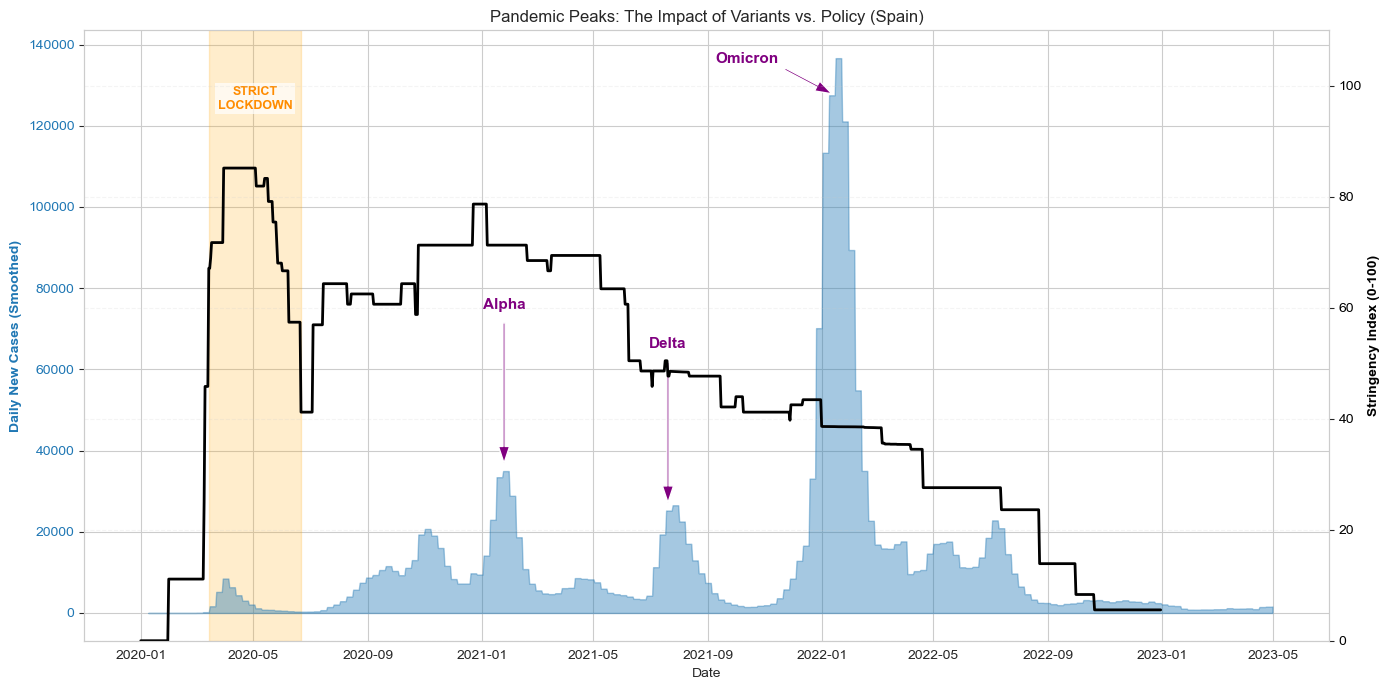

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filtramos datos (España)
country_check = 'Spain'
df_country = countries[countries['country'] == country_check].sort_values('date')
df_country['date'] = pd.to_datetime(df_country['date']) 

# 2. Configuración de fechas
lockdown_start = pd.to_datetime('2020-03-14')
lockdown_end = pd.to_datetime('2020-06-21')

# Fechas de los picos (Cimas de la ola)
variants_peaks = {
    'Alpha': '2021-01-25',   
    'Delta': '2021-07-20',
    'Omicron': '2022-01-15' 
}

# 3. Crear figura
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- FONDO: LOCKDOWN (Zona Naranja) ---
ax1.axvspan(lockdown_start, lockdown_end, color='orange', alpha=0.2)
mid_point = lockdown_start + (lockdown_end - lockdown_start) / 2
y_max = df_country['new_cases_smoothed'].max()
ax1.text(mid_point, y_max * 0.95, 'STRICT\nLOCKDOWN', color='darkorange', 
         ha='center', va='top', fontweight='bold', fontsize=9, 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# --- EJE IZQUIERDO: CASOS (Área Azul) ---
color_cases = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily New Cases (Smoothed)', color=color_cases, fontweight='bold')
ax1.fill_between(df_country['date'], df_country['new_cases_smoothed'], color=color_cases, alpha=0.4, label='New Cases')
ax1.tick_params(axis='y', labelcolor=color_cases)

# --- EJE DERECHO: STRINGENCY (Línea Negra) ---
ax2 = ax1.twinx()
color_lockdown = 'black'
ax2.set_ylabel('Stringency Index (0-100)', color=color_lockdown, fontweight='bold')
ax2.plot(df_country['date'], df_country['stringency_index'], color=color_lockdown, linewidth=2, linestyle='-', label='Policy Stringency')
ax2.tick_params(axis='y', labelcolor=color_lockdown)
ax2.set_ylim(0, 110)

# --- ANOTACIONES: FLECHAS A LOS PICOS ---
for name, date_str in variants_peaks.items():
    target_date = pd.to_datetime(date_str)
    
    # Buscamos el valor real más cercano
    closest_idx = (df_country['date'] - target_date).abs().idxmin()
    row = df_country.loc[closest_idx]
    actual_date = row['date']
    y_val = row['new_cases_smoothed']
    
    # CONFIGURACIÓN PERSONALIZADA POR VARIANTE
    if name == 'Omicron':
        # Truco: Movemos el TEXTO 60 días a la izquierda, pero la flecha sigue en su sitio
        text_date = actual_date - pd.Timedelta(days=60)
        # Alineamos a la derecha para que el texto "termine" en la flecha
        align = 'right'
        offset_y = 8000 
    else:
        text_date = actual_date
        align = 'center'
        offset_y = 40000

    ax1.annotate(name, 
                 xy=(actual_date, y_val),             # Punta de la flecha (en el pico real)
                 xytext=(text_date, y_val + offset_y), # Texto (desplazado si es Omicron)
                 arrowprops=dict(facecolor='purple', shrink=0.05, width=1.5, headwidth=8),
                 color='purple', fontweight='bold', ha=align,
                 fontsize=11)

# Título y Grid
plt.title(f'Pandemic Peaks: The Impact of Variants vs. Policy ({country_check})')
ax2.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

This visualization contextualizes the epidemiological curve with two critical external factors: **Government Interventions** and **COVID Variants** in Spain.

1.  **The Orange Zone (Strict Confinement):**
    The highlighted area marks the initial "State of Alarm" (March - June 2020).
    * **Insight:** During this period, the Stringency Index peaked (>80), and mobility was virtually halted. This "Hammer" approach successfully reset the case count to near zero, proving the efficacy of extreme social distancing before vaccines existed.

2.  **The Variant Waves:**
    Vertical lines mark the emergence of major Variants of Concern (VoC):
    * **Alpha (Late 2020):** Coincides with the third wave. Despite high stringency, cases spiked higher than in 2020, showing the virus was becoming more transmissible.

    * **Delta (Summer 2021):** A rapid spike in cases during a period of relaxed restrictions.
    
    * **Omicron (Late 2021):** The "Game Changer." The graph shows a massive explosion in cases (vertical blue wall) that dwarfs all previous waves. However, notice the **Stringency Index (Black Line)** continues to drop. This visual divergence illustrates the strategic shift: governments stopped trying to suppress transmission via lockdowns and relied on vaccine-induced immunity to prevent severe outcomes.

## Summary

Throughout this notebook, we have reconstructed the timeline of the COVID-19 pandemic, identifying three distinct phases defined by the interaction between the virus, policies, and science.

**1. Phase I: The Shock & The Hammer (2020)**
* **Context:** A naive population facing a novel virus.
* **Action:** Governments relied on **maximum stringency (Index > 80)**. Our analysis of the lockdowns confirms that early mobility restrictions (NPIs) were highly effective at resetting the curve, but unsustainable as a long-term solution.

**2. Phase II: The Arms Race (2021)**
* **Context:** The virus evolved into more dangerous variants (**Alpha, Delta**) while humanity rushed to vaccinate.
* **The Race:** As visualized in our "Shield Effect" chart, 2021 was a race between viral evolution and vaccine distribution. While the "Green Shield" of immunity began to form, it was not yet robust enough to prevent significant mortality peaks during the Delta wave.
* **Pattern:** We also identified a clear **seasonal component**, with major surges occurring during Northern Hemisphere winters.

**3. Phase III: The Shield & The Decoupling Effect (2022 - Onwards)**
* **Context:** The **Omicron** variant caused the highest infection rates in history.
* **The Turning Point:** We proved the existence of the **"Decoupling Effect"**. As the global vaccination coverage (the Green Area) reached critical mass, the correlation between Cases and Deaths broke.
* **Visual Evidence:** Despite Omicron being the most contagious wave, the "Red Line" of deaths remained suppressed. The immunity shield acted as a buffer, preventing a catastrophe.
* **Outcome:** This allowed governments to relax the Stringency Index, marking the definitive transition from pandemic to endemic management.

> **Next Step:** Now that we understand *when* things happened and *how* we solved it (moving from Lockdowns to Vaccines), we need to understand *where* it hit the hardest. 

In the next notebook, we will perform a **Geographical Analysis** to find out why some countries performed better than others.